# 8.20 — Cross-temporal decoding (binary variables)

Reuses the **binary decoders saved by 8.11** (`difficulty_level` / `choice` / `hmm_state`, all
`{0,1}`). For each variable and every (train bin, test bin) across the task epochs, apply that
variable's trained decoder to its held-out test pseudo-population → accuracy, giving a
**cross-temporal generalization matrix** per variable (Fig 5c/5e).

**Plots (current):** one **separate cross-temporal heatmap per variable** (train time × test time),
per prior direction; the **baseline** epoch is dropped from the axes. Cross-variable
generalization (applying one variable's decoder to another) is still **computed and saved** to
`decoding_cross_8.20.pkl` (the off-diagonal `(A, B)` matrices) but is **not shown** for now.

Accuracy only (no significance — that's the shuffle-null step in 8.10/8.11). Reuse is valid because
trial counts are identical across epochs, so a repeat's train/test split is the same across epochs.
The cross-evaluation is skipped when the saved pkl exists (`FORCE_RERUN=True` recomputes it).


In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import pickle
import numpy as np
import torch
import torch.nn as nn

from imports import *  # Path, np, pd, plt
from config import dir_config, ephys_config
from src.utils import decoding_utils

processed_dir = Path(dir_config.data.processed)
alignments    = list(ephys_config["alignment_settings_GP"].keys())
binary_vars   = ["difficulty_level", "choice", "hmm_state"]
var_title     = {"difficulty_level": "difficulty", "choice": "choice", "hmm_state": "hmm_state"}

session_to_exclude = ["210210_GP_JP", "241209_GP_TZ"]
session_metadata = pd.read_csv(processed_dir / "sessions_metadata.csv")
session_metadata = session_metadata[~session_metadata.session_id.isin(session_to_exclude)].reset_index(drop=True)
neuron_metadata = pd.read_csv(processed_dir / "neuron_metadata.csv")
neuron_metadata = neuron_metadata[~neuron_metadata.session_id.isin(session_to_exclude)].reset_index(drop=True)
with open(processed_dir / "glm_hmm_models" / "glm_hmm_masked_final.pkl", "rb") as f:
    glm_hmm = pickle.load(f)

trial_info = decoding_utils.prepare_trial_info(session_metadata, glm_hmm)
trial_info = trial_info[(trial_info.outcome == 1) & (trial_info.reaction_time >= 250)].reset_index(drop=True)
trial_info["abs_coherence"] = trial_info.signed_coherence.abs()


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/HONGYE/opt/anaconda3/envs/prior-sc/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/HONGYE/opt/anaconda3/envs/prior-sc/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/Users/HONGYE/opt/anaconda3/envs/prior-sc/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/HONGYE/opt/anaconda3/envs/prior-sc/lib/python3.11/site-packages/traitlets/con

In [3]:
# --- decoder model (must match 8.10/8.11 arch for state_dict reload) ---
class LinearDecoder(nn.Module):
    def __init__(self, n_input, n_classes, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(nn.BatchNorm1d(n_input), nn.Dropout(dropout), nn.Linear(n_input, n_classes))
    def forward(self, x):
        return self.net(x)

In [4]:
# --- reuse saved cross results if present; otherwise load 8.11 models + ephys for a recompute ---
FORCE_RERUN = False
cross_path = processed_dir / "decoder" / "decoding_cross_8.20.pkl"

recompute = FORCE_RERUN or not cross_path.exists()
if not recompute:
    with open(cross_path, "rb") as f:
        saved = pickle.load(f)
    cross, global_bins, binary_vars = saved["cross"], saved["global_bins"], saved["binary_vars"]
    print(f"loaded existing {cross_path.name} (set FORCE_RERUN=True to recompute the cross-evaluation)")
else:
    with open(processed_dir / "decoder" / "decoding_models_8.11.pkl", "rb") as f:
        bundle = pickle.load(f)
    models_all = bundle["models"]
    N_TEST    = bundle["hyperparams"]["n_test"]
    N_REPEATS = bundle["hyperparams"]["n_repeats"]
    print("decoder arch:", bundle["decoder_arch"], "| N_TEST", N_TEST, "| N_REPEATS", N_REPEATS)

    try:
        ephys_data  # noqa: F821
        print("ephys_data already loaded.")
    except NameError:
        with open(processed_dir / "ephys_neuron_wise.pkl", "rb") as f:
            ephys_data = pickle.load(f)
        print("loaded ephys_neuron_wise.pkl")

loaded existing decoding_cross_8.20.pkl (set FORCE_RERUN=True to recompute the cross-evaluation)


In [5]:
# --- cross-evaluate: for each direction, all (train var A, test var B) x (train bin, test bin) ---
# (skipped if the saved cross pkl was loaded above; set FORCE_RERUN=True to recompute)
if recompute:
    cross = {}          # cross[direction][(A,B)] = (G, G) accuracy matrix
    global_bins = {}    # global_bins[direction] = [(alignment, local_bin, t0, t1, centre_ms), ...]

    for direction in ["toRF", "awayRF"]:
        di = trial_info[trial_info.prior_direction == direction].reset_index(drop=True)
        sessions = sorted(di.session_id.unique())
        session_data, neuron_positions, n_total, label_values = decoding_utils.get_session_trial_data(
            sessions, di, neuron_metadata, ephys_data, alignments)
        dmodels = models_all[direction]["decode"]
        assert n_total == models_all[direction]["n_input"], "neuron count mismatch vs saved models"

        # global bins = concat each epoch's saved bin_edges (same across variables)
        gb = []
        for al in alignments:
            for bi, (t0, t1) in enumerate(dmodels["difficulty_level"][al]["bin_edges"]):
                gb.append((al, bi, t0, t1, int(dmodels["difficulty_level"][al]["centres"][bi])))
        global_bins[direction] = gb
        G = len(gb)
        print(f"\n[{direction}] {n_total} neurons, {G} global bins")

        def build_test(var, gj, r):
            """Rebuild var's held-out test pseudo-population at global bin gj for repeat r -> (tensor, y)."""
            al, _, t0, t1, _ = gb[gj]
            info = dmodels[var][al]["fitted"]; vals = dmodels[var][al]["label_values"]
            test_idx = info["splits"][r]["test_idx"]
            X = np.zeros((len(vals) * N_TEST, n_total))
            for vi, vv in enumerate(vals):
                s0 = vi * N_TEST
                for sid in info["eligible_sessions"]:
                    mask = session_data[al][sid][var] == vv
                    rate = session_data[al][sid]["spikes"][mask][:, :, t0:t1].mean(-1)
                    X[s0:s0 + N_TEST, neuron_positions[sid]] = rate[test_idx[(vi, sid)]]
            return (torch.tensor(X, dtype=torch.float32),
                    torch.tensor(np.repeat(np.arange(len(vals)), N_TEST), dtype=torch.long))

        def load_model(var, gi, r):
            al, bi, *_ = gb[gi]
            ncl = len(dmodels[var][al]["label_values"])
            m = LinearDecoder(n_total, ncl); m.load_state_dict(dmodels[var][al]["fitted"]["models"][(r, bi)]); m.eval()
            return m

        cross[direction] = {(A, B): np.zeros((G, G)) for A in binary_vars for B in binary_vars}
        for r in range(N_REPEATS):
            test_cache = {(B, gj): build_test(B, gj, r) for B in binary_vars for gj in range(G)}
            for A in binary_vars:
                for gi in range(G):
                    model = load_model(A, gi, r)
                    with torch.no_grad():
                        for B in binary_vars:
                            for gj in range(G):
                                Xb, yb = test_cache[(B, gj)]
                                pred = model(Xb).argmax(1)
                                cross[direction][(A, B)][gi, gj] += (pred == yb).float().mean().item()
            print(f"  repeat {r + 1}/{N_REPEATS}", end="\r")
        for k in cross[direction]:
            cross[direction][k] /= N_REPEATS
        print()

    with open(cross_path, "wb") as f:
        pickle.dump({"cross": cross, "global_bins": global_bins, "binary_vars": binary_vars}, f)
    print("saved", cross_path.name)
else:
    print("using loaded cross results; skipping cross-evaluation")

using loaded cross results; skipping cross-evaluation


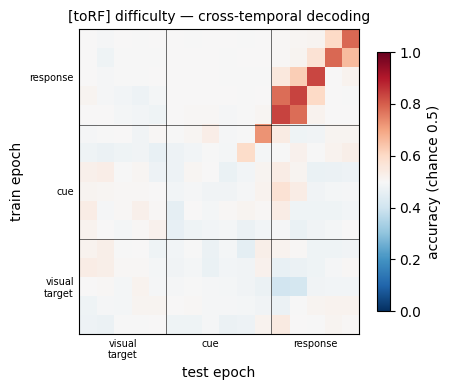

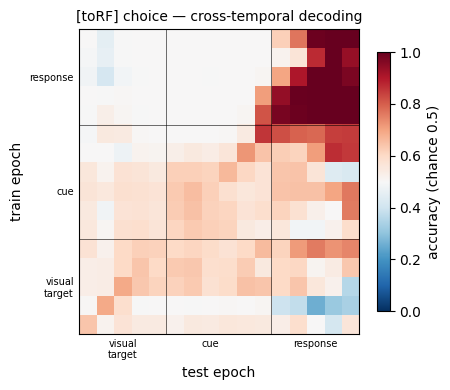

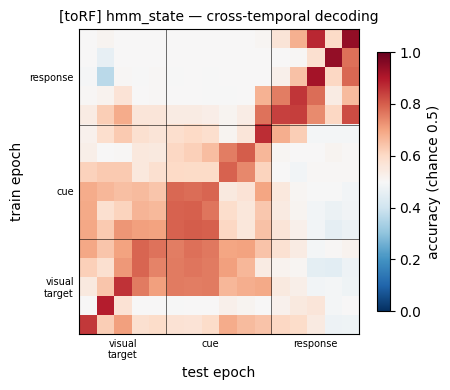

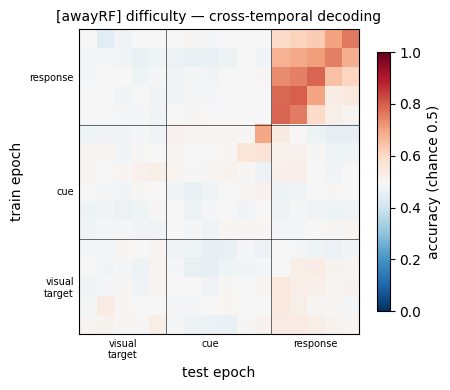

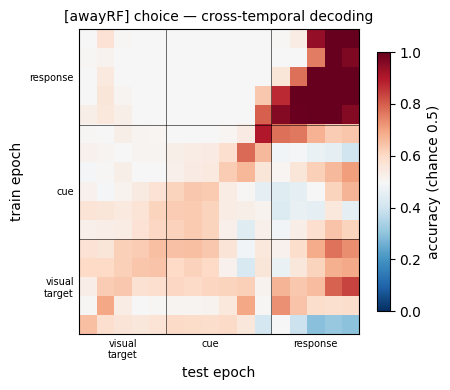

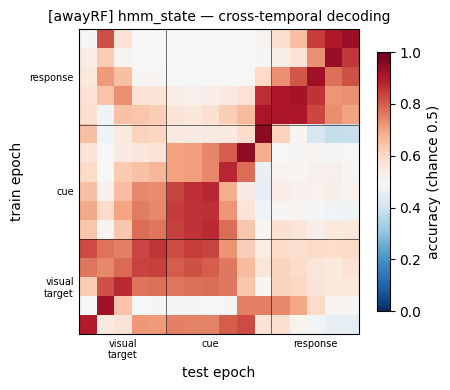

In [6]:
# --- plot: cross-temporal decoding per variable (diagonal only), one separate figure each ---
# Cross-variable (off-diagonal) pairs are still computed & saved by the cell above, but not shown here.
# Baseline epoch is dropped from the axes.
for direction in cross:
    gb_full = global_bins[direction]
    keep = [i for i, g in enumerate(gb_full) if g[0] != "baseline"]           # drop baseline bins
    gb = [gb_full[i] for i in keep]
    G = len(gb)
    epoch_seq = [g[0] for g in gb]
    epochs_shown = [al for al in alignments if al != "baseline"]
    bounds = [i for i in range(1, G) if epoch_seq[i] != epoch_seq[i - 1]]      # epoch transitions
    tick_pos, tick_lab = [], []                                               # epoch label at each epoch centre
    for al in epochs_shown:
        idx = [i for i, e in enumerate(epoch_seq) if e == al]
        if idx:
            tick_pos.append(int(np.mean(idx))); tick_lab.append(al if al != "visual" else "visual\ntarget")

    for A in binary_vars:                                                      # one separate figure per variable
        M = cross[direction][(A, A)][np.ix_(keep, keep)]                       # within-variable cross-temporal
        fig, ax = plt.subplots(figsize=(4.6, 4.0))
        im = ax.imshow(M, origin="lower", cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
        for b in bounds:
            ax.axhline(b - 0.5, c="k", lw=0.4); ax.axvline(b - 0.5, c="k", lw=0.4)
        ax.set_xticks(tick_pos); ax.set_yticks(tick_pos)
        ax.set_xticklabels(tick_lab, fontsize=7); ax.set_yticklabels(tick_lab, fontsize=7)
        ax.tick_params(length=0)                                              # epoch labels, no tick marks
        ax.set_xlabel("test epoch"); ax.set_ylabel("train epoch")
        ax.set_title(f"[{direction}] {var_title[A]} — cross-temporal decoding", fontsize=10)
        fig.colorbar(im, ax=ax, shrink=0.85, label="accuracy (chance 0.5)")
        plt.tight_layout(); plt.show()